In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Missing Values:

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


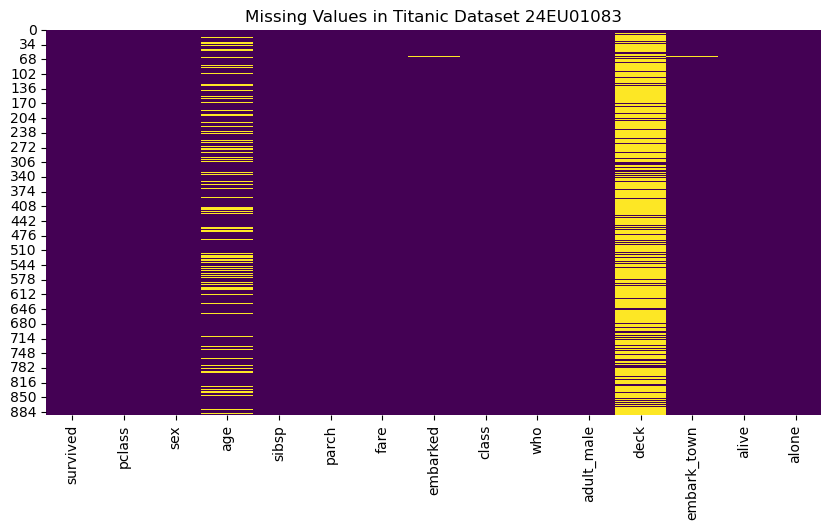

In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values in Titanic Dataset 24EU01083")
plt.show()

In [4]:
print("Missing Values Before Preprocessing:\n")
print(df.isnull().sum())

if "age" in df.columns:
    df["age"] = df["age"].fillna(df["age"].mean())

if "embarked" in df.columns:
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

if "embark_town" in df.columns:
    df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

if "deck" in df.columns:
    df = df.drop(columns=["deck"])

df = df.drop_duplicates()

print("\nMissing Values After Preprocessing:\n")
print(df.isnull().sum())

print("\nDataset After Preprocessing:")
df.head()

Missing Values Before Preprocessing:

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing Values After Preprocessing:

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Dataset After Preprocessing:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [5]:
le = LabelEncoder()

categorical_columns = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "embark_town",
    "alive",
    "alone"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

scaler = StandardScaler()

numerical_columns = ["age", "fare"]

existing_columns = [col for col in numerical_columns if col in df.columns]

df[existing_columns] = scaler.fit_transform(df[existing_columns])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,-0.569164,1,0,-0.528033,2,2,1,1,2,0,0
1,1,1,0,0.598711,1,0,0.697956,0,0,2,0,0,1,0
2,1,3,0,-0.277195,0,0,-0.515109,2,2,2,0,2,1,1
3,1,1,0,0.379735,1,0,0.349817,2,0,2,0,2,1,0
4,0,3,1,0.379735,0,0,-0.512716,2,2,1,1,2,0,1


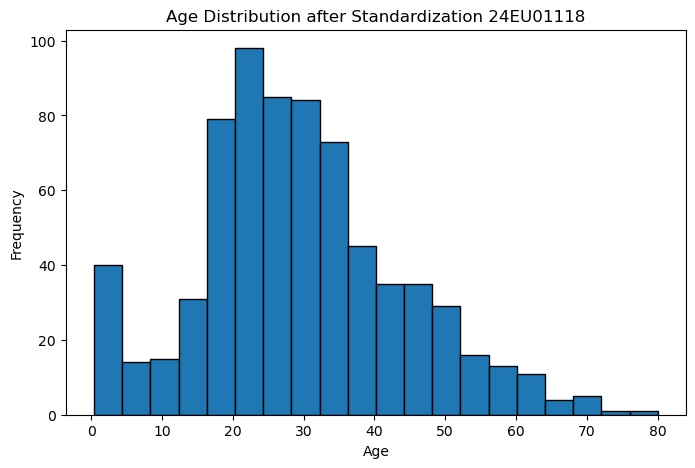

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20, edgecolor="black")
plt.title("Age Distribution after Standardization 24EU01118")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [19]:
df.to_csv("Titanic_Preprocessed.csv", index=False)

print("Preprocessing Completed Successfully!")

df.head()

Preprocessing Completed Successfully!


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,-0.569164,1,0,-0.528033,2,2,1,1,2,0,0
1,1,1,0,0.598711,1,0,0.697956,0,0,2,0,0,1,0
2,1,3,0,-0.277195,0,0,-0.515109,2,2,2,0,2,1,1
3,1,1,0,0.379735,1,0,0.349817,2,0,2,0,2,1,0
4,0,3,1,0.379735,0,0,-0.512716,2,2,1,1,2,0,1
